# Poisson Solver Demo: Uniform Polar Grid

This notebook demonstrates solving the 2D Poisson equation on a disk domain $D = \{(r, \theta) : 0 \le r \le R\}$ in polar coordinates:

$$\Delta u = f(r, \theta) \quad \text{in } D$$
$$u(R, \theta) = g(\theta) \quad \text{on } \partial D \quad \text{(Dirichlet)}$$

### Problem & Parameter Configuration:
- **Domain Radius**: $R = 1.0$
- **Grid Dimensions**: $N = 64$ (angular points), $M = 64$ (radial points)
- **Analytical Solution**: $u(x, y) = 3 e^{x+y} (x - x^2)(y - y^2) + 5$
- **RHS Forcing Function**: $\Delta u = 6 e^{x+y} x y (-3 + x + y + x y)$
- **Boundary Data $g(\theta)$**: $u(R \cos\theta, R \sin\theta)$
- **Radial Quadrature**: `quad_rule = 1` (Trapezoidal 1-step recurrence)
- **Boundary Choice**: `BC_choice = 1` (Dirichlet problem)
- **Radial Discretization**: `rad_unif = 1` (Equidistant radial grid)
- **Angular Solver**: `grid_type = 1` (Uniform FFT via FFTW / cuFFT)
- **Backend Selection**: Configurable CPU (`USE_GPU = False`) or GPU (`USE_GPU = True`)

In [1]:
import os
import sys

# ---------------------------------------------------------
# Backend & Environment Configuration
# ---------------------------------------------------------
USE_GPU = False  # Set to True for NVIDIA GPU (CuPy/cuFFT), False for CPU (FFTW)

# Auto-detect Google Colab environment
IN_COLAB = "google.colab" in sys.modules or os.environ.get("COLAB_GPU") is not None

if IN_COLAB:
    if not os.path.exists("Poisson_Solver"):
        os.system("git clone https://github.com/CharliePyle4/NUFFTRR_Poisson.git")
        if os.path.exists("NUFFTRR_Poisson"):
            os.chdir("NUFFTRR_Poisson")
    os.system("pip install -r requirements.txt -q")
    if USE_GPU:
        os.system("pip install cufinufft -q")

import numpy as np
import matplotlib.pyplot as plt

from Poisson_Solver.grids import (
    generate_uniform_radial,
    generate_uniform_azimuthal,
    generate_cartesian_grid_on_disk,
    plot_grid,
    compute_zero_mode
)
from Poisson_Solver.visualization import (
    plot_on_disk_with_error,
    compute_error_metrics
)
from Poisson_Solver.poisson_solver import poisson_solver

backend_name = "GPU (NVIDIA CuPy / cuFFT)" if USE_GPU else "CPU (Multithreaded FFTW)"
print("=" * 55)
print(f"  Executing Poisson Solver on: {backend_name}")
print("=" * 55)

  Executing Poisson Solver on: CPU (Multithreaded FFTW)


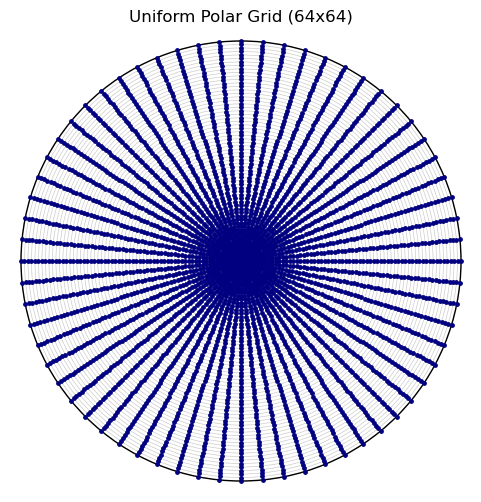

In [2]:
# 1. Define problem domain and resolution
R = 1.0
N = 64  # Number of angular points
M = 64  # Number of radial points

# Generate uniform radial and azimuthal coordinates
r_m = generate_uniform_radial(M, R)
theta_j = generate_uniform_azimuthal(N)
x_coord, y_coord = generate_cartesian_grid_on_disk(theta_j, r_m)

# Visualize the uniform polar grid
fig, ax = plt.subplots(figsize=(6, 6))
plot_grid(ax, theta_j, r_m, R, title=f"Uniform Polar Grid ({N}x{M})", color="navy")
plt.show()

In [3]:
# 2. Define problem functions (Borges & Daripa Problem 1)
def u_exact(x, y):
    return 3 * np.exp(x + y) * (x - x**2) * (y - y**2) + 5

def f_rhs(x, y):
    return 6 * np.exp(x + y) * x * y * (-3 + x + y + x * y)

# Evaluate exact solution and forcing on grid
u_true = u_exact(x_coord, y_coord)
f_values = f_rhs(x_coord, y_coord)
g_values = u_true[:, -1]  # Dirichlet boundary values at outer radius r = R

# Compute central zero mode
u_0 = compute_zero_mode(u_true, theta_j, azu_unif=2)

In [4]:
# 3. Execute the Poisson Solver
u_approx = poisson_solver(
    f_values=f_values,
    g_values=g_values,
    u_fourier_0=u_0,
    N=N,
    M=M,
    r_m=r_m,
    theta_j=theta_j,
    R=R,
    quad_rule=1,       # 1: Trapezoidal, 2: Simpson
    BC_choice=1,       # 1: Dirichlet, 2: Neumann
    rad_unif=1,        # 1: Uniform radial grid
    grid_type=1,       # 1: Uniform angular grid (FFT)
    num_processors=None,
    use_gpu=USE_GPU
)

In [5]:
# 4. Calculate and print error metrics
linf, linf_rel, l2, l2_rel = compute_error_metrics(u_approx, u_true, r_m, theta_j)

print("=" * 55)
print(f"  Poisson Solver Results (Uniform Polar Grid on {backend_name})")
print("=" * 55)
print(f"  Max Error (L_inf):       {linf:.4e}")
print(f"  Relative L_inf Error:    {linf_rel:.4e}")
print(f"  L2 Error:                {l2:.4e}")
print(f"  Relative L2 Error:       {l2_rel:.4e}")
print("=" * 55)

  Poisson Solver Results (Uniform Polar Grid on CPU (Multithreaded FFTW))
  Max Error (L_inf):       2.7574e-05
  Relative L_inf Error:    4.5481e-06
  L2 Error:                2.3659e-05
  Relative L2 Error:       2.6607e-06


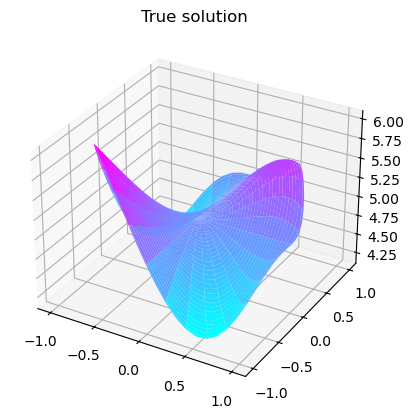

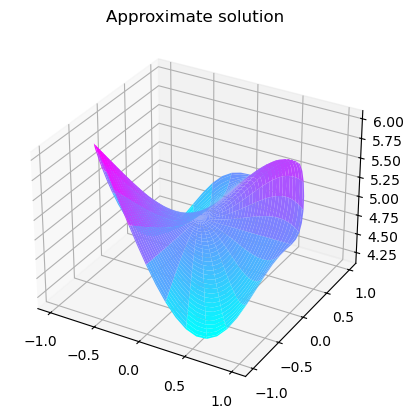

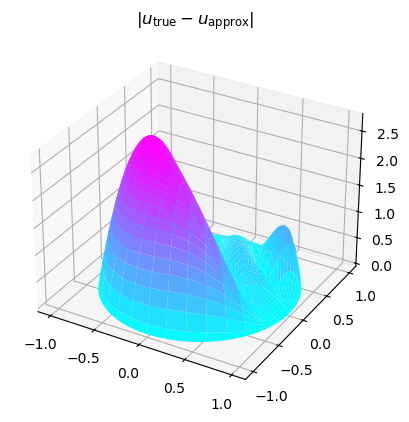

In [6]:
# 5. Plot True Solution, Approximate Solution, and Pointwise Error
plot_on_disk_with_error(x_coord, y_coord, u_approx, u_true)